# Часть 1

### 1.1

In [62]:
from sqlalchemy import create_engine, text
import pandas as pd

engine = create_engine("sqlite:///marketplace (1).db")

query = """
SELECT
    c.category_name,
    COALESCE(SUM(oi.quantity * oi.unit_price * (1 - oi.discount_pct/100.0)), 0) AS revenue,
    COUNT(DISTINCT o.order_id) AS orders_count,
    CASE
        WHEN COUNT(DISTINCT o.order_id) = 0 THEN 0
        ELSE COALESCE(SUM(oi.quantity * oi.unit_price * (1 - oi.discount_pct/100.0)), 0) / COUNT(DISTINCT o.order_id)
    END AS avg_check
FROM categories c
LEFT JOIN products p ON p.category_id = c.category_id
LEFT JOIN order_items oi ON oi.product_id = p.product_id
LEFT JOIN orders o ON o.order_id = oi.order_id AND o.status = 'completed'
GROUP BY c.category_id, c.category_name
ORDER BY revenue DESC;
"""

df = pd.read_sql(text(query), engine)


In [63]:
df

,category_name,revenue,orders_count,avg_check
0,Electronics,6.595740e+07,2794,23606.798584
1,Home & Kitchen,6.437998e+07,2583,24924.496886
2,Beauty,4.193111e+07,2134,19649.068959
3,Sports,4.020283e+07,1861,21602.809256
4,Books,3.806060e+07,2024,18804.643514
5,Toys,3.021771e+07,1728,17487.099495


Electronics и Home & Kitchen - лидеры по выручке (≈66 млн и ≈64 млн тенге), и их отрыв от остальных категорий обеспечен в первую очередь количеством заказов (2794 и 2583), а не средним чеком. При этом по среднему чеку лидирует именно Home & Kitchen (≈24 924 тг), а не Electronics (≈23 607 тг) - то есть категория "Дом и кухня" продаёт немного реже, но более дорогими позициями за заказ. Toys и Books - категории с наименьшей выручкой и самым низким средним чеком (≈17 487 и ≈18 805 тг соответственно), что логично для недорогих товаров.

### 1.2

In [64]:
query_1_2 = """
WITH product_revenue AS (
    SELECT
        p.product_id,
        p.product_name,
        c.category_id,
        c.category_name,
        SUM(oi.quantity * oi.unit_price * (1 - oi.discount_pct/100.0)) AS revenue
    FROM products p
    JOIN categories c ON c.category_id = p.category_id
    JOIN order_items oi ON oi.product_id = p.product_id
    JOIN orders o ON o.order_id = oi.order_id AND o.status = 'completed'
    GROUP BY p.product_id, p.product_name, c.category_id, c.category_name
),
ranked AS (
    SELECT
        *,
        RANK() OVER (PARTITION BY category_id ORDER BY revenue DESC) AS rank_in_category,
        revenue / SUM(revenue) OVER (PARTITION BY category_id) AS share_in_category
    FROM product_revenue
)
SELECT
    category_name,
    product_name,
    revenue,
    rank_in_category,
    share_in_category
FROM ranked
WHERE rank_in_category <= 3
ORDER BY category_name, rank_in_category;
"""

df_1_2 = pd.read_sql(text(query_1_2), engine)
df_1_2

,category_name,product_name,revenue,rank_in_category,share_in_category
0,Beauty,Lip Balm Trio Mini,3.806807e+06,1,0.101200
1,Beauty,Nail Kit Pro,3.072018e+06,2,0.081666
2,Beauty,Face Serum,2.869635e+06,3,0.076286
3,Books,Mystery Novel Plus,4.282197e+06,1,0.125255
4,Books,Data Science Handbook Plus,3.488690e+06,2,0.102045
5,Books,Kids Atlas Pro,3.415686e+06,3,0.099909
6,Electronics,Smart Watch,4.823963e+06,1,0.080057
7,Electronics,Monitor 24in,4.590302e+06,2,0.076179
8,Electronics,Mechanical Keyboard,4.255398e+06,3,0.070621
9,Home & Kitchen,Storage Boxes XL,5.827314e+06,1,0.099063


Ни в одной категории топ-товар не доминирует критично - максимальная доля одного товара в выручке категории составляет всего ~13% (Mystery Novel Plus в Books), у остальных лидеров категорий доля держится в диапазоне 7–12%. Это означает, что выручка внутри каждой категории распределена относительно равномерно между разными товарами - рмск потерять значительную часть выручки категории из-за проблем с одним конкретным товаром невысок.

### 1.3

In [65]:
query = """
WITH monthly AS (
    SELECT
        strftime('%Y-%m', o.order_ts) AS month,
        COALESCE(SUM(oi.quantity * oi.unit_price * (1 - oi.discount_pct/100.0)), 0) AS revenue
    FROM orders o
    JOIN order_items oi ON oi.order_id = o.order_id
    WHERE o.status = 'completed'
    GROUP BY strftime('%Y-%m', o.order_ts)
)
SELECT
    month,
    revenue,
    SUM(revenue) OVER (ORDER BY month) AS cumulative_revenue,
    LAG(revenue) OVER (ORDER BY month) AS prev_month_revenue,
    ROUND(
        (revenue - LAG(revenue) OVER (ORDER BY month)) * 100.0
        / NULLIF(LAG(revenue) OVER (ORDER BY month), 0), 2
    ) AS mom_growth_pct
FROM monthly
ORDER BY month;
"""

df_monthly = pd.read_sql(text(query), engine)
df_monthly

,month,revenue,cumulative_revenue,prev_month_revenue,mom_growth_pct
0,2024-01,6.021226e+05,6.021226e+05,NaN,NaN
1,2024-02,1.238370e+06,1.840493e+06,6.021226e+05,105.67
2,2024-03,1.444601e+06,3.285094e+06,1.238370e+06,16.65
3,2024-04,2.348640e+06,5.633734e+06,1.444601e+06,62.58
4,2024-05,3.585722e+06,9.219456e+06,2.348640e+06,52.67
5,2024-06,3.814370e+06,1.303383e+07,3.585722e+06,6.38
6,2024-07,4.391347e+06,1.742517e+07,3.814370e+06,15.13
7,2024-08,4.990461e+06,2.241563e+07,4.391347e+06,13.64
8,2024-09,6.218966e+06,2.863460e+07,4.990461e+06,24.62
9,2024-10,7.104329e+06,3.573893e+07,6.218966e+06,14.24


Выручка демонстрирует устойчивый рост на протяжении всего периода - с примерно 0.6 млн тенге в январе 2024 до 31.8 млн в декабре 2025, то есть почти в 50 раз. Рост не был равномерным: заметны сезонные пики в ноябре-декабре (вероятно, связанные с праздничным спросом), а также единственный крупный спад в январе 2025 (-32% к декабрю)

### 1.4

In [66]:
query_gaps = """
SELECT
    customer_id,
    order_id,
    order_ts,
    ROW_NUMBER() OVER (PARTITION BY customer_id ORDER BY order_ts) AS order_seq,
    ROUND(julianday(order_ts) - julianday(LAG(order_ts) OVER (PARTITION BY customer_id ORDER BY order_ts)), 1) AS days_since_prev
FROM orders
WHERE status = 'completed'
ORDER BY customer_id, order_ts;
"""
df_gaps = pd.read_sql(text(query_gaps), engine)

query_median = """
WITH ordered AS (
    SELECT
        customer_id,
        order_id,
        order_ts,
        ROW_NUMBER() OVER (PARTITION BY customer_id ORDER BY order_ts) AS order_seq,
        julianday(order_ts) - julianday(LAG(order_ts) OVER (PARTITION BY customer_id ORDER BY order_ts)) AS days_since_prev
    FROM orders
    WHERE status = 'completed'
),
first_to_second AS (
    SELECT customer_id, days_since_prev AS gap_1_2
    FROM ordered
    WHERE order_seq = 2
),
ranked_gaps AS (
    SELECT
        gap_1_2,
        ROW_NUMBER() OVER (ORDER BY gap_1_2) AS rn,
        COUNT(*) OVER () AS total_n
    FROM first_to_second
)
SELECT ROUND(AVG(gap_1_2), 2) AS median_days_between_1st_2nd_order
FROM ranked_gaps
WHERE rn IN ((total_n + 1) / 2, (total_n + 2) / 2);
"""
df_median = pd.read_sql(text(query_median), engine)
df_median

,median_days_between_1st_2nd_order
0,24.85


Медианный интервал между первой и второй покупкой составляет примерно 24.85 дня. Это значит, что большинство покупателей, которые вообще возвращаются за вторым заказом, делают это довольно быстро - примерно через 3.5 недели после первой покупки. Имеет смысл напоминать о себе клиенту через 2-3 недели после первого заказа, пока интерес ещё не остыл

### 1.5

In [67]:
query = """
WITH daily AS (
    SELECT
        strftime('%Y-%m-%d', o.order_ts) AS day,
        COALESCE(SUM(oi.quantity * oi.unit_price * (1 - oi.discount_pct/100.0)), 0) AS revenue
    FROM orders o
    JOIN order_items oi ON oi.order_id = o.order_id
    WHERE o.status = 'completed'
    GROUP BY strftime('%Y-%m-%d', o.order_ts)
)
SELECT
    day,
    revenue,
    ROUND(AVG(revenue) OVER (ORDER BY day ROWS BETWEEN 6 PRECEDING AND CURRENT ROW), 2) AS revenue_7d_moving_avg
FROM daily
ORDER BY day;
"""

df_rolling = pd.read_sql(text(query), engine)
df_rolling

,day,revenue,revenue_7d_moving_avg
0,2024-01-01,1.232106e+04,12321.06
1,2024-01-02,2.865715e+04,20489.10
2,2024-01-03,1.529282e+04,18757.01
3,2024-01-04,1.080502e+04,16769.01
4,2024-01-08,4.716423e+04,22848.06
...,...,...,...
695,2025-12-27,1.143692e+06,980380.62
696,2025-12-28,1.312067e+06,1031158.87
697,2025-12-29,6.063677e+05,979172.43
698,2025-12-30,9.033181e+05,907109.95


Скользящее среднее выручки выросло почти в 50 раз за два года - с примерно 20 тысяч тенге в день в начале 2024 до более 1 миллиона тенге в день к концу 2025, что подтверждает устойчивый рост, увиденный в 1.3, но уже сглаженный от резких дневных всплесков и провалов

### 1.6

In [68]:
query = """
WITH ordered AS (
    SELECT
        customer_id,
        order_ts,
        ROW_NUMBER() OVER (PARTITION BY customer_id ORDER BY order_ts) AS order_seq,
        julianday(order_ts) - julianday(LAG(order_ts) OVER (PARTITION BY customer_id ORDER BY order_ts)) AS days_since_prev
    FROM orders
    WHERE status = 'completed'
),
customer_flags AS (
    SELECT
        customer_id,
        MAX(CASE WHEN order_seq = 1 THEN 1 ELSE 0 END) AS made_first_order,
        MAX(CASE WHEN order_seq = 2 AND days_since_prev <= 90 THEN 1 ELSE 0 END) AS second_order_within_90d
    FROM ordered
    GROUP BY customer_id
),
cohorts AS (
    SELECT
        c.customer_id,
        strftime('%Y-%m', c.signup_date) AS cohort_month,
        COALESCE(cf.made_first_order, 0) AS made_first_order,
        COALESCE(cf.second_order_within_90d, 0) AS second_order_within_90d
    FROM customers c
    LEFT JOIN customer_flags cf ON cf.customer_id = c.customer_id
)
SELECT
    cohort_month,
    SUM(made_first_order) AS customers_with_first_order,
    SUM(second_order_within_90d) AS customers_second_order_90d,
    ROUND(100.0 * SUM(second_order_within_90d) / NULLIF(SUM(made_first_order), 0), 2) AS pct_second_order_within_90d
FROM cohorts
GROUP BY cohort_month
ORDER BY cohort_month;
"""

df_cohort = pd.read_sql(text(query), engine)
df_cohort

,cohort_month,customers_with_first_order,customers_second_order_90d,pct_second_order_within_90d
0,NaN,162,40,24.69
1,2024-01,79,24,30.38
2,2024-02,61,23,37.70
3,2024-03,75,21,28.00
4,2024-04,87,27,31.03
5,2024-05,75,23,30.67
6,2024-06,80,31,38.75
7,2024-07,71,38,53.52
8,2024-08,95,47,49.47
9,2024-09,82,43,52.44


Доля покупателей, вернувшихся за вторым заказом в течение 90 дней, выросла с 25-30% в начале 2024 года до 60-70% к концу 2025 - сильный рост удержания клиентов, скорее всего, отражает улучшение продукта или сервиса со временем.

# Часть 2

In [69]:
import pandas as pd
import numpy as np
import re
from sqlalchemy import create_engine, text

engine = create_engine("sqlite:///marketplace (1).db")
raw = {t: pd.read_sql(text(f"SELECT * FROM {t}"), engine) for t in
       ['categories','products','customers','orders','order_items','sessions','returns']}

quality_report = []

def log_issue(table, column, issue, rows_affected, action, reason):
    quality_report.append({
        'table': table, 'column': column, 'issue': issue,
        'rows_affected': rows_affected, 'action': action, 'reason': reason
    })


def clean_customers(df):
    df = df.copy()

    def parse_date(s):
        s = s.strip()
        for fmt in ('%Y-%m-%d', '%Y/%m/%d', '%m/%d/%Y', '%d.%m.%Y'):
            try:
                return pd.to_datetime(s, format=fmt).strftime('%Y-%m-%d')
            except ValueError:
                continue
        return None
    before = df['signup_date'].copy()
    df['signup_date'] = df['signup_date'].apply(parse_date)
    n_reformatted = (before != df['signup_date']).sum()
    log_issue('customers', 'signup_date', 'Смешанные форматы дат (ISO, MM/DD/YYYY, YYYY/MM/DD, DD.MM.YYYY)',
               n_reformatted, 'Приведено к единому формату YYYY-MM-DD', 'Формат мешает сортировке/группировке по датам')

    city_map = {
        'almaty': 'Almaty', 'alma-ata': 'Almaty',
        'astana': 'Astana', 'нур-султан': 'Astana', 'nur-sultan': 'Astana',
        'shymkent': 'Shymkent', 'chimkent': 'Shymkent',
        'karaganda': 'Karaganda', 'qaraghandy': 'Karaganda',
        'aktobe': 'Aktobe', 'aqtobe': 'Aktobe',
    }
    n_missing_city = df['city'].isna().sum()
    def normalize_city(c):
        if pd.isna(c):
            return c
        key = c.strip().lower()
        return city_map.get(key, c.strip())
    before_city = df['city'].copy()
    df['city'] = df['city'].apply(normalize_city)
    n_city_fixed = (before_city.fillna('') != df['city'].fillna('')).sum()
    log_issue('customers', 'city', 'Несогласованные написания городов (регистр, пробелы, старые названия, транслит)',
               n_city_fixed, 'Приведено к 5 каноничным названиям городов', 'Разное написание не даёт корректно группировать/сравнивать города (нужно для 3.3)')
    log_issue('customers', 'city', 'Пропуски', n_missing_city, 'Оставлено как NaN', 'Город неизвестен — не является ошибкой, удалять нельзя (потеряем покупателя)')

    bad_year = ((df['birth_year'] < 1920) | (df['birth_year'] > 2015))
    n_bad_year = bad_year.sum()
    df.loc[bad_year, 'birth_year'] = np.nan
    log_issue('customers', 'birth_year', 'Невозможные значения (0, 2035 и т.п.)', n_bad_year,
               'Заменено на NaN', 'Год рождения вне разумного диапазона — явная ошибка ввода, не выброс')

    n_missing_email = df['email'].isna().sum()
    log_issue('customers', 'email', 'Пропуски', n_missing_email, 'Оставлено как NaN', 'Email не обязателен, не ошибка')

    dupe_mask = df.duplicated(subset=['full_name', 'signup_date'], keep='first')
    n_dupes = dupe_mask.sum()
    df_deduped = df[~dupe_mask].copy()
    log_issue('customers', 'ALL (customer_id)', 'Один и тот же человек зарегистрирован дважды под разными customer_id',
               n_dupes, 'Оставлена одна запись на человека (первая по customer_id)', 'Не дубликат PK, а дубликат сущности — искажает подсчёт уникальных клиентов')

    return df_deduped


def clean_products(df):
    df = df.copy()

    n_missing_cat = df['category_id'].isna().sum()
    log_issue('products', 'category_id', 'Пропуски', n_missing_cat, 'Оставлено как NaN', 'Товар без категории — не ошибка, редкий legit случай')

    def parse_price(v):
        if isinstance(v, str):
            return float(re.sub(r'[^\d.]', '', v))
        return v
    mask_str = df['list_price'].apply(lambda x: isinstance(x, str))
    n_str_price = mask_str.sum()
    df['list_price'] = df['list_price'].apply(parse_price).astype(float)
    log_issue('products', 'list_price', 'Строковые значения с суффиксом валюты (напр. "3990 KZT") вместо числа',
               n_str_price, 'Извлечено число, приведено к float', 'Неверный тип данных не позволяет использовать столбец в расчётах')

    return df


def clean_orders(df):
    df = df.copy()

    struct_missing = df['delivery_days'].isna() & df['status'].isin(['cancelled', 'pending'])
    genuine_missing = df['delivery_days'].isna() & df['status'].isin(['completed', 'returned'])
    log_issue('orders', 'delivery_days', 'Пропуск (структурный): заказ отменён/в ожидании, доставки физически не было',
               struct_missing.sum(), 'Оставлено как NaN', 'Информативный пропуск — заполнение исказит анализ сроков доставки')
    log_issue('orders', 'delivery_days', 'Пропуск (немотивированный) у завершённых/возвращённых заказов',
               genuine_missing.sum(), 'Оставлено как NaN, исключать из анализа доставки явно', 'Заказ доставлен, но срок не записан — вероятно, сбой сбора данных; заполнение средним исказило бы 3.3')

    n_missing_promo = df['promo_code'].isna().sum()
    log_issue('orders', 'promo_code', 'Пропуски', n_missing_promo, 'Оставлено как NaN (означает "без промокода")', 'Структурный пропуск: большинство заказов оформляются без промокода — это норма')

    return df


def clean_order_items(df, valid_order_ids):
    df = df.copy()

    orphan_mask = ~df['order_id'].isin(valid_order_ids)
    n_orphan = orphan_mask.sum()
    df = df[~orphan_mask].copy()
    log_issue('order_items', 'order_id', 'Нарушение ссылочной целостности: order_id не существует в orders',
               n_orphan, 'Строки удалены', 'Позицию заказа нельзя привязать ни к одному существующему заказу')

    zero_q = df['quantity'] == 0
    n_zero_q = zero_q.sum()
    df = df[~zero_q].copy()
    log_issue('order_items', 'quantity', 'Нулевое количество товара', n_zero_q, 'Строки удалены', 'Заказ 0 штук товара не имеет экономического смысла')

    neg_q = df['quantity'] < 0
    n_neg_q = neg_q.sum()
    df.loc[neg_q, 'quantity'] = df.loc[neg_q, 'quantity'].abs()
    log_issue('order_items', 'quantity', 'Отрицательное количество товара', n_neg_q,
               'Взято по модулю (абсолютное значение)', 'Похоже на ошибку ввода знака (возвраты трекаются отдельной таблицей returns)')

    n_missing_price = df['unit_price'].isna().sum()
    med_by_product = df.groupby('product_id')['unit_price'].transform('median')
    df['unit_price'] = df['unit_price'].fillna(med_by_product)
    log_issue('order_items', 'unit_price', 'Пропуски', n_missing_price,
               'Заполнено медианной ценой по этому же товару', 'Медиана по товару — разумная оценка, устойчивая к выбросам')

    return df


def clean_sessions(df):
    df = df.copy()
    n_missing_cust = df['customer_id'].isna().sum()
    log_issue('sessions', 'customer_id', 'Пропуски', n_missing_cust, 'Оставлено как NaN (гостевая сессия)', 'Информативный пропуск: визит без входа в аккаунт')
    return df


def clean_returns(df):
    df = df.copy()
    n_missing_reason = df['reason'].isna().sum()
    log_issue('returns', 'reason', 'Пропуски', n_missing_reason, 'Оставлено как NaN', 'Причина возврата не всегда указывается')
    return df


customers_clean = clean_customers(raw['customers'])
products_clean = clean_products(raw['products'])
orders_clean = clean_orders(raw['orders'])
order_items_clean = clean_order_items(raw['order_items'], set(orders_clean['order_id']))
sessions_clean = clean_sessions(raw['sessions'])
returns_clean = clean_returns(raw['returns'])
categories_clean = raw['categories'].copy()  


quality_report_df = pd.DataFrame(quality_report)
quality_report_df

,table,column,issue,rows_affected,action,reason
0,customers,signup_date,"Смешанные форматы дат (ISO, MM/DD/YYYY, YYYY/M...",193,Приведено к единому формату YYYY-MM-DD,Формат мешает сортировке/группировке по датам
1,customers,city,"Несогласованные написания городов (регистр, пр...",321,Приведено к 5 каноничным названиям городов,Разное написание не даёт корректно группироват...
2,customers,city,Пропуски,43,Оставлено как NaN,"Город неизвестен — не является ошибкой, удалят..."
3,customers,birth_year,"Невозможные значения (0, 2035 и т.п.)",12,Заменено на NaN,Год рождения вне разумного диапазона — явная о...
4,customers,email,Пропуски,60,Оставлено как NaN,"Email не обязателен, не ошибка"
5,customers,ALL (customer_id),Один и тот же человек зарегистрирован дважды п...,44,Оставлена одна запись на человека (первая по c...,"Не дубликат PK, а дубликат сущности — искажает..."
6,products,category_id,Пропуски,4,Оставлено как NaN,"Товар без категории — не ошибка, редкий legit ..."
7,products,list_price,"Строковые значения с суффиксом валюты (напр. ""...",3,"Извлечено число, приведено к float",Неверный тип данных не позволяет использовать ...
8,orders,delivery_days,Пропуск (структурный): заказ отменён/в ожидани...,598,Оставлено как NaN,Информативный пропуск — заполнение исказит ана...
9,orders,delivery_days,Пропуск (немотивированный) у завершённых/возвр...,429,"Оставлено как NaN, исключать из анализа достав...","Заказ доставлен, но срок не записан — вероятно..."


Итоговый отчёт показывает 18 найденных проблем в 6 таблицах: смешанные форматы дат и разнобой в написании городов у customers, невозможные значения года рождения, задвоенные записи одного и того же человека под разными customer_id, "грязная" цена у трёх товаров, структурные и немотивированные пропуски в сроке доставки, нарушение ссылочной целостности и некорректные количества в order_items. Реальное число уникальных покупателей - 2391, а не 2435: 44 записи оказались одним и тем же человеком, зарегистрированным дважды. Там, где пропуск информативен (например, отсутствие промокода или отсутствие customer_id у гостевой сессии), значения оставлены как есть, а не заполнены искусственно, чтобы не исказить дальнейший анализ.

# Часть 3

### 3.1

Среднее:            31,279.72
Медиана:             22,427.40
Стандартное отклон.: 30,294.64
IQR:                 34,205.07
Асимметрия (skew):   1.871
Эксцесс (kurtosis):  4.866

Мода: максимум 2 повторение(-я) на 8157 уникальных значений — мода здесь не несёт смысла, это просто случайное совпадение сумм у двух заказов.


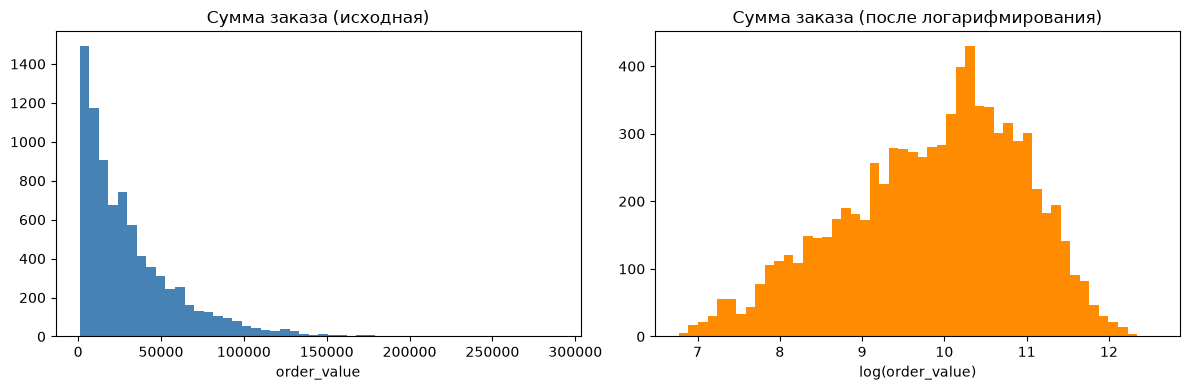

In [70]:
from scipy import stats
import numpy as np

order_items_valid = order_items_clean.copy()
order_items_valid['line_revenue'] = (order_items_valid['quantity'] * order_items_valid['unit_price']
                                      * (1 - order_items_valid['discount_pct'] / 100.0))

order_value = order_items_valid.groupby('order_id')['line_revenue'].sum().reset_index()
order_value.columns = ['order_id', 'order_value']

completed_ids = set(orders_clean.loc[orders_clean['status'] == 'completed', 'order_id'])
order_value = order_value[order_value['order_id'].isin(completed_ids)].copy()

mean_val = order_value['order_value'].mean()
median_val = order_value['order_value'].median()
std_val = order_value['order_value'].std()
q1, q3 = order_value['order_value'].quantile([0.25, 0.75])
iqr_val = q3 - q1
skew_val = order_value['order_value'].skew()
kurt_val = order_value['order_value'].kurtosis()

print(f"Среднее:            {mean_val:,.2f}")
print(f"Медиана:             {median_val:,.2f}")
print(f"Стандартное отклон.: {std_val:,.2f}")
print(f"IQR:                 {iqr_val:,.2f}")
print(f"Асимметрия (skew):   {skew_val:.3f}")
print(f"Эксцесс (kurtosis):  {kurt_val:.3f}")

mode_counts = order_value['order_value'].value_counts()
print(f"\nМода: максимум {mode_counts.max()} повторение(-я) на {len(mode_counts)} уникальных значений — "
      f"мода здесь не несёт смысла, это просто случайное совпадение сумм у двух заказов.")

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(order_value['order_value'], bins=50, color='steelblue')
axes[0].set_title('Сумма заказа (исходная)')
axes[0].set_xlabel('order_value')

axes[1].hist(np.log(order_value['order_value']), bins=50, color='darkorange')
axes[1].set_title('Сумма заказа (после логарифмирования)')
axes[1].set_xlabel('log(order_value)')

plt.tight_layout()
plt.show()

Среднее (31 279.72) заметно выше медианы (22 427.40) из-за сильной правой асимметрии распределения (skew примерно 1.87) - большинство заказов относительно недорогие, но немногочисленные крупные заказы (максимум 288 865) сильно тянут среднее вверх. Для отчёта руководству правильнее использовать медиану, потому что она устойчива к выбросам и честно показывает типичный заказ, тогда как среднее создаёт завышенное впечатление о типичных тратах клиента. Мода в данном случае не несёт смысла - совпадение сумм произошло случайно всего у одной пары заказов из 8157. После логарифмирования распределение становится заметно ближе к симметричному, колоколообразному виду.

### 3.2

In [71]:
from scipy import stats
import numpy as np

items_per_order = order_items_clean.groupby('order_id').size().reset_index(name='n_items')
completed_ids = set(orders_clean.loc[orders_clean['status'] == 'completed', 'order_id'])
items_per_order = items_per_order[items_per_order['order_id'].isin(completed_ids)]

mean_n = items_per_order['n_items'].mean()
var_n = items_per_order['n_items'].var()
print(f"Среднее: {mean_n:.3f}, Дисперсия: {var_n:.3f}, отношение var/mean: {var_n/mean_n:.3f}")


lam = mean_n - 1
print(f"Оценка lambda: {lam:.4f}")

observed_counts = items_per_order['n_items'].value_counts().sort_index()
k_values = observed_counts.index.values
n_total = len(items_per_order)

expected_probs = stats.poisson.pmf(k_values - 1, lam)
expected_counts = expected_probs * n_total

comparison = pd.DataFrame({
    'n_items': k_values,
    'observed': observed_counts.values,
    'expected': expected_counts.round(1)
})
print(comparison)

mask_small = comparison['expected'] < 5
tail_obs = comparison.loc[mask_small, 'observed'].sum()
tail_exp = comparison.loc[mask_small, 'expected'].sum()
main = comparison.loc[~mask_small]
obs_final = np.array(list(main['observed']) + [tail_obs])
exp_final = np.array(list(main['expected']) + [tail_exp])
exp_final = exp_final * (obs_final.sum() / exp_final.sum()) 

chi2_stat, p_value = stats.chisquare(f_obs=obs_final, f_exp=exp_final, ddof=1)
print(f"\nchi2 = {chi2_stat:.3f}, p-value = {p_value:.4f}")

Среднее: 1.791, Дисперсия: 0.809, отношение var/mean: 0.451
Оценка lambda: 0.7914
   n_items  observed  expected
0        1      3741    3697.4
1        2      2858    2926.0
2        3      1167    1157.8
3        4       319     305.4
4        5        60      60.4
5        6        12       9.6
6        8         1       0.1

chi2 = 11.474, p-value = 0.0428


Число позиций в заказе хорошо описывается сдвинутым распределением Пуассона (N = 1 + Poisson(lambda), lambda примерно 0.79) - у каждого заказа гарантированно есть минимум одна позиция по определению, а сверх неё товары добавляются независимо друг от друга, что теоретически соответствует свойствам распределения Пуассона. Критерий хи-квадрат даёт p-value = 0.043 - формально ниже порога 0.05, но при сравнении наблюдаемых и ожидаемых частот (см. таблицу выше) расхождения минимальны, поэтому распределение можно считать разумным приближением.

### 3.3

n = 7745, skew = 15.24
Аномальные заказы (>100 дней доставки): 31 — исключены как ошибка данных


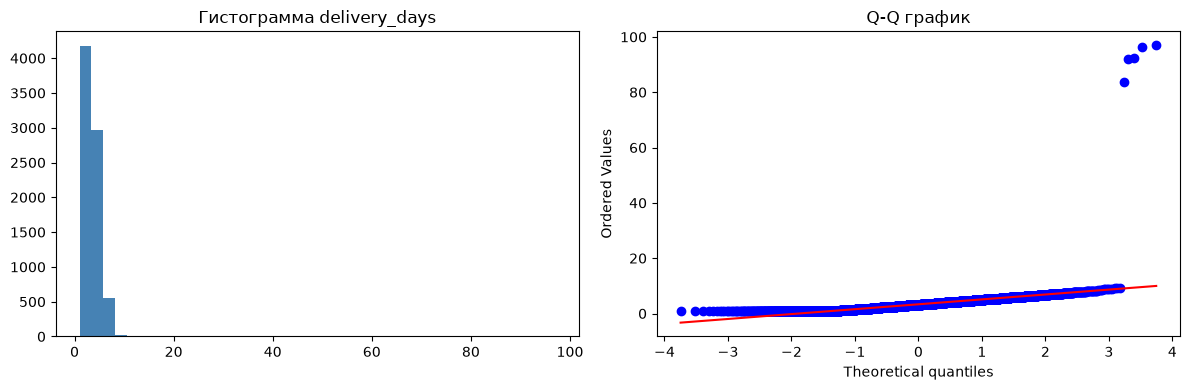

D'Agostino K^2 test: statistic=17502.28, p-value=0.00e+00
           count      mean  median       std
city                                        
Aktobe      1009  4.414272     4.4  1.513201
Almaty      2631  2.807526     2.6  3.287260
Astana      1955  2.924501     2.7  2.551757
Karaganda    782  3.608056     3.6  1.595199
Shymkent    1151  4.121633     4.0  3.052969

Kruskal-Wallis (все города): H=1202.0, p=5.87e-259
Almaty (медиана 2.6) vs Astana (медиана 2.7): p=0.0001, effect size r=0.067
Almaty (медиана 2.6) vs Aktobe (медиана 4.4): p=0.0000, effect size r=0.591


In [72]:
from scipy import stats
import matplotlib.pyplot as plt


completed = orders_clean[orders_clean['status'] == 'completed'].copy()
dd = completed['delivery_days'].dropna()

print(f"n = {len(dd)}, skew = {dd.skew():.2f}")


print("Аномальные заказы (>100 дней доставки):", (dd > 100).sum(), "— исключены как ошибка данных")
dd_valid = dd[dd <= 100]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(dd_valid, bins=40, color='steelblue')
axes[0].set_title('Гистограмма delivery_days')
stats.probplot(dd_valid, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q график')
plt.tight_layout()
plt.show()

stat, p = stats.normaltest(dd_valid)
print(f"D'Agostino K^2 test: statistic={stat:.2f}, p-value={p:.2e}")

dd_city = completed[completed['delivery_days'] <= 100].merge(
    customers_clean[['customer_id', 'city']], on='customer_id', how='left'
).dropna(subset=['city', 'delivery_days'])

print(dd_city.groupby('city')['delivery_days'].agg(['count', 'mean', 'median', 'std']))

groups = [g['delivery_days'].values for _, g in dd_city.groupby('city')]
h_stat, p_kw = stats.kruskal(*groups)
print(f"\nKruskal-Wallis (все города): H={h_stat:.1f}, p={p_kw:.2e}")

def mannwhitney_with_effect(df, city1, city2):
    g1 = df.loc[df['city'] == city1, 'delivery_days']
    g2 = df.loc[df['city'] == city2, 'delivery_days']
    u_stat, p_val = stats.mannwhitneyu(g1, g2, alternative='two-sided')
    n1, n2 = len(g1), len(g2)
    effect_size = 1 - (2 * u_stat) / (n1 * n2)  
    return city1, city2, g1.median(), g2.median(), p_val, effect_size

for c1, c2 in [('Almaty', 'Astana'), ('Almaty', 'Aktobe')]:
    city1, city2, med1, med2, p_val, r = mannwhitney_with_effect(dd_city, c1, c2)
    print(f"{city1} (медиана {med1}) vs {city2} (медиана {med2}): p={p_val:.4f}, effect size r={r:.3f}")

delivery_days категорически не распределён нормально (skew примерно 15, формальный тест даёт p приблизительно 0) - гистограмма показывает резкий пик у малых значений с длинным хвостом, Q-Q график подтверждает сильное отклонение от нормальности. Обнаружена дополнительная проблема с данными: 31 заказ имеет нереалистичный срок доставки (164-199 дней), эти значения распределены по городам пропорционально и похожи на технический сбой, поэтому исключены из сравнения городов. Сравнение городов между собой показывает неоднородную картину: Almaty и Astana доставляют практически одинаково (разница статистически значима из-за большой выборки, но размер эффекта пренебрежимо мал, r = 0.067), а вот Aktobe и Shymkent реально отстают почти в 1.5-1.6 раза от Almaty (эффект большой, r = 0.59) - именно туда стоит обратить внимание операционному отделу.

### 3.4

In [73]:
from scipy import stats
import numpy as np

crosstab = pd.crosstab(sessions_clean['device'], sessions_clean['converted'])
print(crosstab)

chi2, p_val, dof, expected = stats.chi2_contingency(crosstab)
print(f"\nchi2 = {chi2:.3f}, p-value = {p_val:.6f}, dof = {dof}")

def conversion_ci(df, device):
    sub = df[df['device'] == device]
    n = len(sub)
    x = sub['converted'].sum()
    p = x / n
    se = np.sqrt(p * (1 - p) / n)
    return {
        'device': device, 'n': n, 'conversions': int(x),
        'rate_%': round(p * 100, 2),
        'ci_95_%': f"[{round((p - 1.96*se)*100, 2)}, {round((p + 1.96*se)*100, 2)}]"
    }

ci_table = pd.DataFrame([conversion_ci(sessions_clean, d) for d in sessions_clean['device'].unique()])
print(ci_table)

converted      0    1
device               
desktop     7334  463
mobile     15593  510
tablet      2011   89

chi2 = 103.103, p-value = 0.000000, dof = 2
    device      n  conversions  rate_%       ci_95_%
0   mobile  16103          510    3.17   [2.9, 3.44]
1  desktop   7797          463    5.94  [5.41, 6.46]
2   tablet   2100           89    4.24   [3.38, 5.1]


Устройство статистически значимо связано с конверсией (chi2 = 103.1, p приблизительно 0). Desktop конвертирует почти вдвое лучше mobile (5.94% против 3.17%), и их 95%-ные доверительные интервалы не пересекаются, значит разница надёжна, а не случайность выборки. При этом mobile даёт больше всего трафика (16 103 сессии из 26 000, почти 62%) - именно мобильная версия сильнее всего теряет потенциальные конверсии и заслуживает первоочередного внимания продуктовой команды.

### 3.5

In [74]:
from scipy import stats
from statsmodels.stats.power import TTestIndPower

order_value_promo = order_value.merge(
    orders_clean.loc[orders_clean['status'] == 'completed', ['order_id', 'promo_code']],
    on='order_id', how='inner'
)
order_value_promo['has_promo'] = order_value_promo['promo_code'].notna()

print(order_value_promo.groupby('has_promo')['order_value'].agg(['count', 'mean', 'median', 'std']))

promo = order_value_promo.loc[order_value_promo['has_promo'], 'order_value']
no_promo = order_value_promo.loc[~order_value_promo['has_promo'], 'order_value']

t_stat, p_val = stats.ttest_ind(promo, no_promo, equal_var=False)
print(f"\nt = {t_stat:.4f}, p-value = {p_val:.4f}")

pooled_std = np.sqrt(((len(promo)-1)*promo.std()**2 + (len(no_promo)-1)*no_promo.std()**2)
                      / (len(promo)+len(no_promo)-2))
cohens_d = mean_diff / pooled_std
print(f"Cohen's d: {cohens_d:.4f}")

power_analysis = TTestIndPower()
required_n = power_analysis.solve_power(effect_size=cohens_d, alpha=0.05, power=0.8, ratio=1.0)
print(f"Требуемый размер выборки на группу (мощность 80%): {round(required_n)}")
print(f"Фактический размер группы 'с промокодом': {len(promo)}")

           count          mean      median           std
has_promo                                               
False       6346  31748.760611  22770.5400  30590.758949
True        1812  29637.032893  20928.5545  29182.758506

t = -2.6874, p-value = 0.0072
Cohen's d: 0.0697
Требуемый размер выборки на группу (мощность 80%): 3229
Фактический размер группы 'с промокодом': 1812


Разница в средней сумме заказа между покупателями с промокодом и без оказалась статистически значимой (p = 0.0072), но направлена неожиданно - заказы с промокодом оказались чуть дешевле (29 637 против 31 749), а не дороже. Размер эффекта крошечный (Cohen's d примерно 0.07), то есть практической ценности для бизнеса эта разница почти не несёт - значимость поймалась в основном за счёт большого объёма выборки. Для надёжного обнаружения эффекта такой величины с мощностью 80% нужно около 3229 наблюдений на группу; при текущих неравных размерах групп достигнутая мощность теста составила около 74.5%, что и объясняет пограничный результат.

# Часть 4

### 4.1

In [75]:
from scipy import stats

eligible = orders_clean[orders_clean['status'].isin(['completed', 'returned'])].copy()

returns_table_ids = set(returns_clean['order_id'])
eligible['was_returned'] = eligible['order_id'].isin(returns_table_ids)

n_total = len(eligible)
n_returned = eligible['was_returned'].sum()
p_return = n_returned / n_total
print(f"P(возврат) = {p_return:.4f} ({p_return*100:.2f}%), n={n_total}")

cod = eligible[eligible['payment_method'] == 'cash_on_delivery']
p_return_given_cod = cod['was_returned'].mean()
print(f"P(возврат | COD) = {p_return_given_cod:.4f} ({p_return_given_cod*100:.2f}%), n={len(cod)}")

p_cod = len(cod) / n_total
p_return_and_cod = ((eligible['was_returned']) & (eligible['payment_method'] == 'cash_on_delivery')).sum() / n_total
print(f"\nP(возврат) * P(COD) = {p_return * p_cod:.4f}")
print(f"P(возврат AND COD) = {p_return_and_cod:.4f}")

eligible['is_cod'] = eligible['payment_method'] == 'cash_on_delivery'
ct = pd.crosstab(eligible['is_cod'], eligible['was_returned'])
chi2, p_val, dof, exp = stats.chi2_contingency(ct)
print(f"\nChi-square тест независимости: chi2={chi2:.3f}, p-value={p_val:.4f}")

P(возврат) = 0.0646 (6.46%), n=8402
P(возврат | COD) = 0.0735 (7.35%), n=1170

P(возврат) * P(COD) = 0.0090
P(возврат AND COD) = 0.0102

Chi-square тест независимости: chi2=1.605, p-value=0.2051


Вероятность возврата заказа составляет 6.46% (543 возврата из 8402 заказов, которые физически могли быть возвращены). При оплате наложенным платежом эта вероятность немного выше - 7.35%, однако формальный chi-square тест показывает, что разница статистически не значима (p = 0.2051) - события "способ оплаты наложенным платежом" и "возврат заказа" можно считать независимыми, наблюдаемое расхождение объясняется случайной изменчивостью выборки.

### 4.2

In [76]:
n_total = len(orders_clean)
n_chargeback = orders_clean['is_chargeback'].sum()
n_flagged = orders_clean['risk_flag'].sum()
n_flagged_and_chargeback = ((orders_clean['risk_flag'] == 1) & (orders_clean['is_chargeback'] == 1)).sum()

p_chargeback = n_chargeback / n_total                         
p_flag = n_flagged / n_total                                    
p_flag_given_chargeback = n_flagged_and_chargeback / n_chargeback  

print(f"P(чарджбэк) = {p_chargeback:.4f} ({p_chargeback*100:.2f}%)")
print(f"P(флаг) = {p_flag:.4f} ({p_flag*100:.2f}%)")
print(f"P(флаг | чарджбэк) = {p_flag_given_chargeback:.4f} ({p_flag_given_chargeback*100:.2f}%)")

p_chargeback_given_flag = (p_flag_given_chargeback * p_chargeback) / p_flag
print(f"\nP(чарджбэк | флаг) = {p_chargeback_given_flag:.4f} ({p_chargeback_given_flag*100:.2f}%)")

P(чарджбэк) = 0.0129 (1.29%)
P(флаг) = 0.0904 (9.04%)
P(флаг | чарджбэк) = 0.8707 (87.07%)

P(чарджбэк | флаг) = 0.1241 (12.41%)


Модель помечает 9.04% заказов, при этом реальная доля мошенничества (чарджбэков) в данных составляет всего 1.29%. Модель ловит 87.07% реальных случаев мошенничества (высокая чувствительность), но по формуле Байеса вероятность того, что помеченный заказ действительно мошеннический, составляет лишь 12.41% - то есть из каждых 8 заказов, попавших под подозрение, реальным мошенничеством оказывается только один. Это классический эффект низкой базовой частоты: даже очень чувствительная модель при редком целевом событии даёт много ложных срабатываний в абсолютных числах, и если каждый флаг ведёт к ручной проверке или блокировке, стоит взвесить цену такого решения для честных клиентов.

### Часть 5

In [77]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Панель 1
query_cat_month = """
SELECT
    strftime('%Y-%m', o.order_ts) AS month,
    c.category_name,
    COALESCE(SUM(oi.quantity * oi.unit_price * (1 - oi.discount_pct/100.0)), 0) AS revenue
FROM orders o
JOIN order_items oi ON oi.order_id = o.order_id
JOIN products p ON p.product_id = oi.product_id
JOIN categories c ON c.category_id = p.category_id
WHERE o.status = 'completed'
GROUP BY strftime('%Y-%m', o.order_ts), c.category_name
ORDER BY month, category_name;
"""
df_cat_month = pd.read_sql(text(query_cat_month), engine)

# Панель 2
completed = orders_clean[orders_clean['status'] == 'completed'].copy()
dd_city = completed[completed['delivery_days'] <= 100].merge(
    customers_clean[['customer_id', 'city']], on='customer_id', how='left'
).dropna(subset=['city', 'delivery_days'])

# Панель 3
def conversion_ci(df, device):
    sub = df[df['device'] == device]
    n = len(sub)
    x = sub['converted'].sum()
    p = x / n
    se = np.sqrt(p * (1 - p) / n)
    return {'device': device, 'n': n, 'rate': p * 100,
            'ci_low': (p - 1.96 * se) * 100, 'ci_high': (p + 1.96 * se) * 100}
panel3_data = pd.DataFrame([conversion_ci(sessions_clean, d) for d in sessions_clean['device'].unique()])
panel3_data = panel3_data.sort_values('rate', ascending=False)

# Панель 4
flag_stats = orders_clean.groupby('risk_flag')['is_chargeback'].agg(['mean', 'count'])
flag_stats.index = ['Не помечен', 'Помечен моделью']
flag_stats['mean_pct'] = flag_stats['mean'] * 100
overall_rate = orders_clean['is_chargeback'].mean() * 100

# Панель 5
query_cohort = """
WITH ordered AS (
    SELECT customer_id, order_ts,
        ROW_NUMBER() OVER (PARTITION BY customer_id ORDER BY order_ts) AS order_seq,
        julianday(order_ts) - julianday(LAG(order_ts) OVER (PARTITION BY customer_id ORDER BY order_ts)) AS days_since_prev
    FROM orders WHERE status = 'completed'
),
customer_flags AS (
    SELECT customer_id,
        MAX(CASE WHEN order_seq=1 THEN 1 ELSE 0 END) AS made_first_order,
        MAX(CASE WHEN order_seq=2 AND days_since_prev<=90 THEN 1 ELSE 0 END) AS second_order_within_90d
    FROM ordered GROUP BY customer_id
)
SELECT strftime('%Y-%m', c.signup_date) AS cohort_month,
    SUM(COALESCE(cf.made_first_order,0)) AS customers_with_first_order,
    SUM(COALESCE(cf.second_order_within_90d,0)) AS customers_second_order_90d
FROM customers c
LEFT JOIN customer_flags cf ON cf.customer_id = c.customer_id
GROUP BY cohort_month
ORDER BY cohort_month;
"""
df_cohort_raw = pd.read_sql(text(query_cohort), engine)
df_cohort_raw = df_cohort_raw.dropna(subset=['cohort_month'])
df_cohort_raw['pct'] = 100 * df_cohort_raw['customers_second_order_90d'] / df_cohort_raw['customers_with_first_order']

# Сборка дашборда
fig = make_subplots(
    rows=3, cols=2,
    specs=[[{"colspan": 2}, None], [{}, {}], [{}, {}]],
    subplot_titles=(
        "Выручка по месяцам в разрезе категорий",
        "Срок доставки по городам", "Конверсия по устройствам (95% ДИ)",
        "Доля чарджбэков: помечен vs не помечен моделью", "Возврат за 2-й покупкой (90 дней) по когортам"
    ),
    row_heights=[0.36, 0.32, 0.32], vertical_spacing=0.1
)

categories_list = sorted(df_cat_month['category_name'].unique())
colors = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA', '#FFA15A', '#19D3F3']
for i, cat in enumerate(categories_list):
    sub = df_cat_month[df_cat_month['category_name'] == cat]
    fig.add_trace(go.Scatter(
        x=sub['month'], y=sub['revenue'], mode='lines', name=cat,
        line=dict(color=colors[i % len(colors)]),
        hovertemplate='%{x}<br>' + cat + ': %{y:,.0f} тг<extra></extra>'
    ), row=1, col=1)

buttons = [dict(label='Все категории', method='update', args=[{'visible': [True]*len(categories_list)}])]
for i, cat in enumerate(categories_list):
    vis = [False]*len(categories_list)
    vis[i] = True
    buttons.append(dict(label=cat, method='update', args=[{'visible': vis}]))
fig.update_layout(updatemenus=[dict(buttons=buttons, direction='down', x=1.0, y=1.15, showactive=True)])

for city in sorted(dd_city['city'].unique()):
    fig.add_trace(go.Box(
        y=dd_city.loc[dd_city['city']==city, 'delivery_days'], name=city, showlegend=False,
        hovertemplate='%{y:.1f} дней<extra></extra>'
    ), row=2, col=1)

fig.add_trace(go.Bar(
    x=panel3_data['device'], y=panel3_data['rate'],
    error_y=dict(type='data', array=panel3_data['ci_high']-panel3_data['rate'],
                 arrayminus=panel3_data['rate']-panel3_data['ci_low']),
    marker_color='#00CC96', showlegend=False,
    hovertemplate='%{x}: %{y:.2f}%<extra></extra>'
), row=2, col=2)

fig.add_trace(go.Bar(
    x=flag_stats.index, y=flag_stats['mean_pct'],
    marker_color=['#00CC96', '#EF553B'], showlegend=False,
    hovertemplate='%{x}: %{y:.2f}%<extra></extra>'
), row=3, col=1)
fig.add_hline(y=overall_rate, line_dash='dash', line_color='gray',
              annotation_text=f'Средний уровень: {overall_rate:.2f}%', row=3, col=1)

fig.add_trace(go.Bar(
    x=df_cohort_raw['cohort_month'], y=df_cohort_raw['pct'],
    marker=dict(color=df_cohort_raw['pct'], colorscale='Viridis'), showlegend=False,
    hovertemplate='%{x}: %{y:.1f}%<extra></extra>'
), row=3, col=2)

fig.update_yaxes(title_text="Выручка, тг", row=1, col=1)
fig.update_yaxes(title_text="Дней", row=2, col=1)
fig.update_yaxes(title_text="Конверсия, %", row=2, col=2)
fig.update_yaxes(title_text="Доля чарджбэков, %", row=3, col=1)
fig.update_yaxes(title_text="Доля 2-й покупки за 90д, %", row=3, col=2)

fig.update_layout(height=1100, title_text="Аналитическая панель: маркетплейс 2024-2025", showlegend=True)
fig.write_html("dashboard.html", include_plotlyjs=True)

In [78]:
fig

Выручка растёт во всех категориях, Electronics и Home & Kitchen - лидеры по абсолютной выручке (переключатель позволяет изолировать любую категорию отдельно). Almaty и Astana доставляют быстрее (медиана 2.6-2.7 дня), Aktobe и Shymkent заметно медленнее (4-4.4 дня), что подтверждает вывод из 3.3. Desktop конвертирует почти вдвое лучше mobile (5.94% против 3.17%), доверительные интервалы не пересекаются. Заказы, помеченные моделью риска, оказываются мошенническими в 12.4% случаев против 0.18% у непомеченных, что подтверждает находку из 4.2, но также показывает масштаб ложных срабатываний. Доля покупателей, вернувшихся за второй покупкой в течение 90 дней, выросла с 25-30% в начале 2024 года до 70-80% к концу 2025, при этом самые последние когорты ещё не успели "дозреть" до полного окна наблюдения.